# **MÓDULO 32 - Exercício**
# Random Forest


Nesta tarefa, vocês vão trabalhar com uma base de dados de avaliações de vinhos, onde o objetivo é prever a pontuação dos vinhos usando o algoritmo de Random Forest para classificação multiclasse.

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("winequality-red.csv", delimiter=',')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


**Vamos conhecer nossa base:**

Características dos Vinhos (Features)

Fixed Acidity: Acidez fixa do vinho.

Volatile Acidity: Acidez volátil do vinho.

Citric Acid: Quantidade de ácido cítrico no vinho.

Residual Sugar: Açúcar residual presente no vinho.

Chlorides: Nível de cloretos no vinho.

Free Sulfur Dioxide: Dióxido de enxofre livre no vinho.

Total Sulfur Dioxide: Quantidade total de dióxido de enxofre no vinho.

Density: Densidade do vinho.

pH: Nível de pH do vinho.

Sulphates: Quantidade de sulfatos no vinho.

Alcohol: Teor alcoólico do vinho.



**Variável de Saída (Target):**

Quality: Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.


Esta abordagem permitirá que vocês explorem como diferentes características químicas influenciam a qualidade dos vinhos e como o Random Forest pode ser usado para fazer previsões precisas com base nesses dados.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [5]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

# 2 - Realize a segunda e terceita etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.

B) Verifique o balanceamento da váriavel Target.(realizado na etapa 3)

C)  Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.

D) Crie um novo dataframe apenas com as váriaveis que parecem ter maior correlação com a target. (Negativa ou positiva)


In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix = df.corr(numeric_only=True)

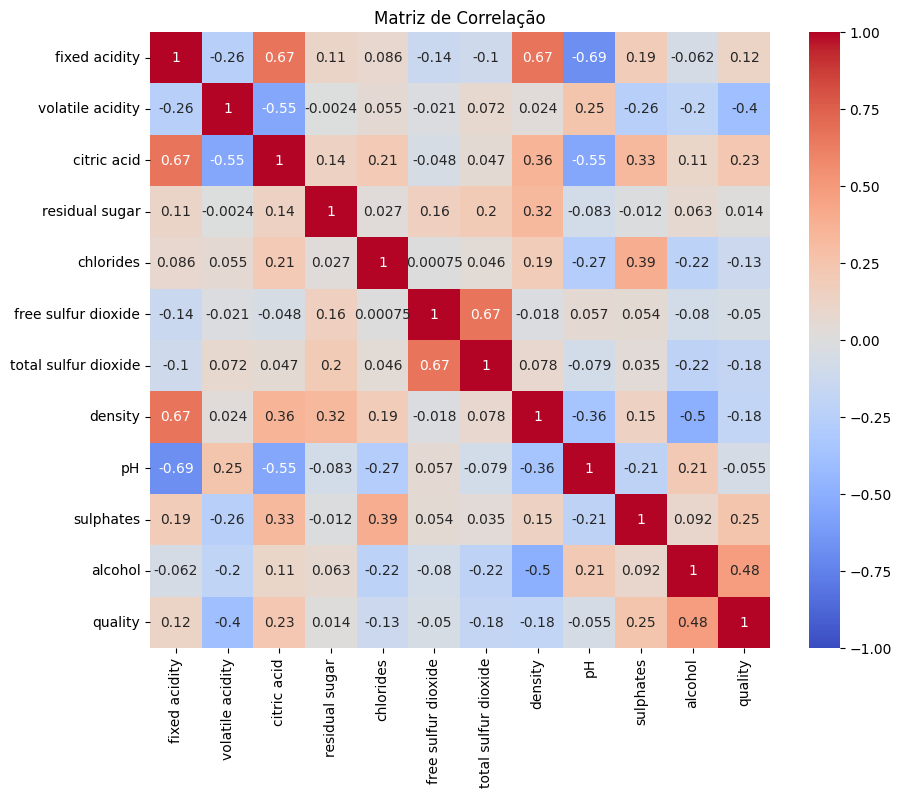

In [22]:

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1,vmax=1)
plt.title('Matriz de Correlação')
plt.show()


As variáveis que se destacam com alguma correlação são: alcohol(+0.48), volatile acidity(-0.40), sulphates(0.25) e citric acid(0.23).

In [30]:
df_novasfeatures = df[['alcohol','volatile acidity','sulphates','citric acid', 'quality']]
df_novasfeatures

,alcohol,volatile acidity,sulphates,citric acid,quality
0,9.4,0.700,0.56,0.00,5
1,9.8,0.880,0.68,0.00,5
2,9.8,0.760,0.65,0.04,5
3,9.8,0.280,0.58,0.56,6
5,9.4,0.660,0.56,0.00,5
...,...,...,...,...,...
1593,9.5,0.620,0.82,0.08,6
1594,10.5,0.600,0.58,0.08,5
1595,11.2,0.550,0.76,0.10,6
1597,10.2,0.645,0.71,0.12,5


# 3 - Preparação Final dos Dados

A) Separe a base em X(Features) e Y(Target)

B) Separe a base em treino e teste.

B) Verifique o balanceamento da váriavel Target.(etapa2)



In [37]:
X= df_novasfeatures.drop('quality', axis=1)
y= df_novasfeatures['quality']
df_novasfeatures['quality'].value_counts()
#Não está balanceada o que pode prejudicar muito o desempenho do modelo.
             

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

In [50]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
sc = StandardScaler()  #padroniza primeiro e dps balanceia só treino
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

smote= SMOTE(random_state = 42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
X_train_balanced
y_train_balanced
y_train_balanced.value_counts()

quality
7    457
5    457
6    457
4    457
3    457
8    457
Name: count, dtype: int64

# 4 - Modelagem

A) Inicie e treine o modelo de Random Forest

B) Aplique a base de teste o modelo.


In [53]:
#inicia
rf_model = RandomForestClassifier(random_state = 42)
#treina
rf_model.fit(X_train, y_train)
#aplica
y_pred = rf_model.predict(X_test)

# 5 - Avaliação

A) Avalie as principais métricas da Claissificação e traga insights acerca do resultado, interprete os valores achados.

B) Você nota que o modelo teve dificuldade para prever alguma classe? Se sim, acredita que tenha relação com o balanceamento dos dados? Explique.


In [60]:
#Avaliação sendo feita considerando quality como uma classificação
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Acurácia:{accuracy:.2f}")
print(f"Relat.", report)
print(f"Matriz de Confusão:", conf_matrix)

Acurácia:0.59
Relat.               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        11
           5       0.67      0.74      0.70       120
           6       0.53      0.57      0.55       103
           7       0.52      0.42      0.46        31
           8       0.00      0.00      0.00         3

    accuracy                           0.59       272
   macro avg       0.29      0.29      0.29       272
weighted avg       0.55      0.59      0.57       272

Matriz de Confusão: [[ 0  0  4  0  0  0]
 [ 0  0  4  7  0  0]
 [ 0  0 89 29  2  0]
 [ 0  0 35 59  8  1]
 [ 0  0  1 16 13  1]
 [ 0  0  0  1  2  0]]


C:\Users\Regina\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Regina\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Regina\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [58]:
print(y.value_counts().sort_index())

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


O modelo apresentou uma acurácia de 59%, classificando corretamente aproximadamente 60% das observações do conjunto de teste. O melhor desempenho foi observado para a nota 5, com F1-score de 0,70 e recall de 74%, seguida pelas notas 6 e 7. Por outro lado, o modelo apresentou grande dificuldade para classificar as notas 3, 4 e 8, que obtiveram F1-score igual a 0. As notas 1, 2, 9 e 10 não aparecem nos resultados porque não possuem observações no conjunto de teste.

Essa dificuldade está relacionada ao desbalanceamento da variável Target, pois as classes 5 e 6 possuem uma quantidade muito maior de observações do que as demais. Foi aplicado o SMOTE para tentar reduzir esse problema por meio da criação de amostras sintéticas das classes minoritárias. Entretanto, o balanceamento não foi suficiente para melhorar o desempenho do modelo de forma significativa, indicando que apenas aumentar a quantidade de exemplos das classes minoritárias não foi suficiente para que o modelo aprendesse seus padrões. Portanto, outros fatores, como a sobreposição das características entre as classes e a própria dificuldade de distinguir notas próximas, também podem estar influenciando o resultado.

# 5 - Melhorando os Hyperparametros

A) Defina o Grid de parametros que você quer testar

B) Inicie e Treine um novo modelo utilizando o random search.

C) Avalie os resultados do modelo.

D) Você identificou melhorias no modelo após aplicar o random search? Justifique.


ps. Essa parte da atividade demorará um pouco para rodar!

In [68]:
param_grid= {
    'n_estimators':[50,100,200],
    'max_depth':[None, 10,20,50],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'max_features':['sqrt','log2',None]
}
random_search = RandomizedSearchCV(estimator = rf_model,  param_distributions=param_grid, n_iter = 100, 
                                   cv=5, n_jobs =-1, verbose = 2, random_state = 42, scoring = 'accuracy')

random_search.fit(X_train, y_train)
best_params = random_search.best_params_
print(f"Melhores hiper:{best_params}")
best_rf_model = random_search.best_estimator_
best_rf_model.fit(X_train, y_train)
y_pred = best_rf_model.predict(X_test)


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Melhores hiper:{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}


In [69]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Acurácia:{accuracy:.2f}")
print(f"Relat.", report)
print(f"Matriz de Confusão:", conf_matrix)

Acurácia:0.62
Relat.               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        11
           5       0.69      0.76      0.72       120
           6       0.56      0.63      0.59       103
           7       0.54      0.42      0.47        31
           8       0.00      0.00      0.00         3

    accuracy                           0.62       272
   macro avg       0.30      0.30      0.30       272
weighted avg       0.58      0.62      0.60       272

Matriz de Confusão: [[ 0  0  4  0  0  0]
 [ 0  0  5  6  0  0]
 [ 0  0 91 28  1  0]
 [ 0  0 30 65  8  0]
 [ 0  0  2 16 13  0]
 [ 0  0  0  1  2  0]]


C:\Users\Regina\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Regina\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Regina\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

O modelo apresentou uma acurácia de 62%, classificando corretamente aproximadamente 62% das observações do conjunto de teste. O melhor desempenho foi observado para a nota 5, com F1-score de 0,72 e recall de 76%, seguida pelas notas 6 e 7, com F1-scores de 0,59 e 0,47, respectivamente. Em comparação com o modelo anterior, houve uma pequena melhora na acurácia, que passou de 59% para 62%, além de uma melhora no desempenho das classes 5, 6 e 7.

Por outro lado, o modelo continuou apresentando grande dificuldade para classificar as notas 3, 4 e 8, que obtiveram F1-score igual a 0. As notas 1, 2, 9 e 10 não aparecem nos resultados porque não possuem observações no conjunto de teste.

# 6 - Chegando a perfeição

Baseado em tudo que você já aprendeu até agora, quais outras técnicas você acredita que poderiam ser aplicadas ao modelo para melhorar ainda mais suas previsões?
Uma das possibilidades seria reduzir a quantidade de categorias da variável Quality agrupando notas próximas. Porque algumas classes possuem poucos/nenhum representantes. Outra possibilidade seria buscar uma quantidade maior de dados, principalmente de vinhos com notas que aparecem poucas vezes na base.Também seria interessante testar outras variáveis e combinações entre as características existentes. Algumas variáveis podem ter pouca correlação individual com Quality, mas, quando combinadas com outras, podem ajudar o modelo a identificar determinados padrões.

Você trabalhou bem no fluxo de dados ao utilizar o Random Forest para a classificação multiclasse do dataset de vinhos. A forma como você preparou o ambiente, tratou o desbalanceamento com o SMOTE, filtrou as variáveis relevantes e aplicou o ajuste de hiperparâmetros pelo RandomizedSearchCV mostra profisisonalismo.

Dicas de melhoria

No seu código, você gerou os dados balanceados X_train_balanced e y_train_balanced na etapa de preparação, porém alimentou o modelo rf_model e o RandomizedSearchCV utilizando a base original X_train e y_train. Certifique-se de passar as variáveis reamostradas ao ajustar o modelo para que o balanceamento surta efeito prático no treinamento.
Como a qualidade do vinho possui notas com pouquíssimas amostras (como 3, 4 e 8), classificar 6 a 10 categorias gera ruído no modelo. Uma estratégia comum é reclassificar a target em categorias mais amplas, como "Ruim" (3 a 5), "Médio" (6) e "Bom" (7 a 8).
Cross-Validation Integrada com Pipeline: Ao aplicar o SMOTE antes de usar o RandomizedSearchCV, é recomendável utilizar a estrutura de Pipeline da biblioteca imblearn. Isso garante que o SMOTE seja aplicado apenas dentro de cada dobra (fold) da validação cruzada, evitando o vazamento de dados (data leakage) e refinando a avaliação técnica.
Na otimização de hiperparâmetros, você usou scoring='accuracy'. Em bases desbalanceadas, a acurácia costuma ser enganosa; alterar esse parâmetro para scoring='f1_weighted' ou scoring='f1_macro' ajudará o algoritmo a focar na performance das classes minoritárias durante a busca pelos melhores parâmetros.
Obs.: As dicas e sugestões não caracterizam a nota final da tarefa, são apenas para melhorar o desenvolvimento do seu trabalho ao longo do curso e na carreira profissional.

Conte comigo

Um abraço

Rodrigo